# PROJECT 2

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bazingasdk","key":"04d2f04a0ee5d194aa3e1919d9a9529f"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:26<00:00, 211MB/s]



### IMPORT LIBRARIES

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### LOAD DATA

In [6]:
df = pd.read_csv("HAM10000_metadata.csv")

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### CLASS DISTRIBUTION

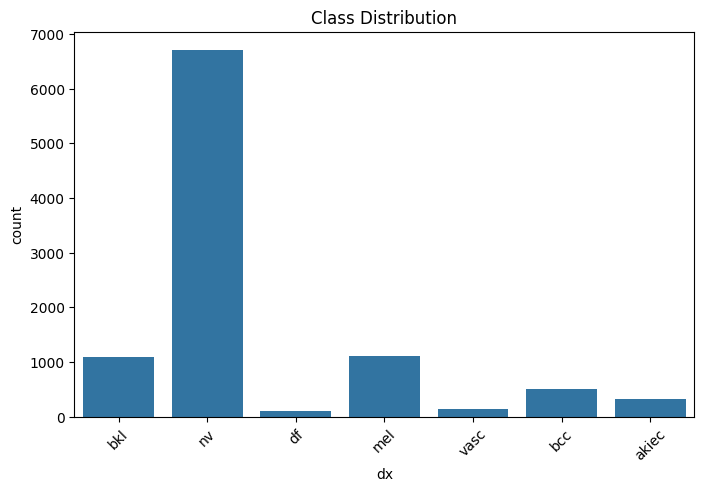

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x="dx", data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

We are seeing : One class very large (nv class) and Melanoma class (mel) very small, This is the core problem : dataset highly imbalanced.

### STRATIFIED SPLIT

split data while preserving class distribution

without stratification model may never see melanoma in training

In [8]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["dx"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["dx"], random_state=42
)

### IMAGE GENERATORS

preprocess and augment images for training

In [9]:
import os, shutil

os.makedirs("images", exist_ok=True)

for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    for file in os.listdir(folder):
        shutil.copy(os.path.join(folder, file), "images")

In [10]:
len(os.listdir("images"))

10015

In [11]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

In [12]:
train_df["image_id"] = train_df["image_id"].apply(lambda x: x + ".jpg")

In [13]:
train_df["image_id"] = train_df["image_id"].str.replace(".jpg.jpg", ".jpg")

In [14]:
train_data = train_gen.flow_from_dataframe(
    train_df,
    directory="images",
    x_col="image_id",
    y_col="dx",
    target_size=(128,128),
    class_mode="categorical"
)

Found 7010 validated image filenames belonging to 7 classes.


In [15]:
val_df["image_id"] = val_df["image_id"] + ".jpg"

In [16]:
val_df["image_id"] = val_df["image_id"].str.replace(".jpg.jpg", ".jpg")

In [17]:
val_data = val_gen.flow_from_dataframe(
    val_df,
    directory="images",
    x_col="image_id",
    y_col="dx",
    target_size=(128,128),
    class_mode="categorical"
)

Found 1502 validated image filenames belonging to 7 classes.


### BASELINE CNN

 to observe initial performance

In [18]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(train_data.class_indices), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 101s 435ms/step - accuracy: 0.6676 - loss: 1.0073 - val_accuracy: 0.6751 - val_loss: 0.9055
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 82s 371ms/step - accuracy: 0.6730 - loss: 0.9145 - val_accuracy: 0.6844 - val_loss: 0.8707
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 81s 369ms/step - accuracy: 0.6854 - loss: 0.8437 - val_accuracy: 0.6931 - val_loss: 0.8261
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 79s 359ms/step - accuracy: 0.7036 - loss: 0.7890 - val_accuracy: 0.7071 - val_loss: 0.7820
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 79s 359ms/step - accuracy: 0.7098 - loss: 0.7714 - val_accuracy: 0.7104 - val_loss: 0.8345
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 80s 363ms/step - accuracy: 0.7311 - loss: 0.7287 - val_accuracy: 0.7383 - val_loss: 0.7319
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 80s 363ms/step - accuracy: 0.7330 - loss: 0.7110 - val_accuracy: 0.7423 - val_loss: 0.7162
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 77s 351ms/step - accuracy: 0.7402 - loss: 

Although the model achieved good accuracy (~74%), it performs poorly on melanoma detection due to class imbalance (bias toward majority class) .The recall for melanoma is low meaning many malignant cases are missed, which is critical in medical diagnosis.

### CLASS WEIGHTS

Handling Class Imbalance with Class Weights

assign higher importance to minority classes.

In [21]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df["dx"])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df["dx"]
)

class_weights = dict(zip(range(len(classes)), weights))

In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 81s 359ms/step - accuracy: 0.4900 - loss: 1.4485 - val_accuracy: 0.4081 - val_loss: 1.4460
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 78s 356ms/step - accuracy: 0.5117 - loss: 1.3610 - val_accuracy: 0.2676 - val_loss: 1.8535
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 77s 349ms/step - accuracy: 0.5300 - loss: 1.2055 - val_accuracy: 0.4181 - val_loss: 2.2086
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 79s 358ms/step - accuracy: 0.5167 - loss: 1.3521 - val_accuracy: 0.5366 - val_loss: 1.1803
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 81s 369ms/step - accuracy: 0.5957 - loss: 1.1026 - val_accuracy: 0.6498 - val_loss: 0.8949
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 79s 361ms/step - accuracy: 0.5809 - loss: 1.0970 - val_accuracy: 0.6292 - val_loss: 0.9396
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 79s 358ms/step - accuracy: 0.6007 - loss: 1.0494 - val_accuracy: 0.5992 - val_loss: 1.1016
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 79s 360ms/step - accuracy: 0.5874 - loss: 1

Model is punished more if it misclassifies melanoma

### EVALUATION

In [24]:
test_df["image_id"] = test_df["image_id"] + ".jpg"

In [25]:
test_df["image_id"] = test_df["image_id"].str.replace(".jpg.jpg", ".jpg")

In [26]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_dataframe(
    test_df,
    directory="images",
    x_col="image_id",
    y_col="dx",
    target_size=(128,128),
    class_mode="categorical",
    shuffle=False
)

Found 1503 validated image filenames belonging to 7 classes.


In [27]:
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)
y_true = test_data.classes

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms/step


In [28]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.21      0.67      0.32        49
           1       0.31      0.36      0.34        77
           2       0.26      0.57      0.35       165
           3       0.06      0.24      0.10        17
           4       0.31      0.47      0.37       167
           5       0.98      0.50      0.66      1006
           6       0.27      0.73      0.40        22

    accuracy                           0.50      1503
   macro avg       0.34      0.50      0.36      1503
weighted avg       0.74      0.50      0.56      1503



### Evaluation Results Analysis

The model achieved an overall accuracy of 50%, which is relatively low.

From the classification report:
- Class 5 has very high precision (0.98) but low recall (0.50), meaning the model is very confident when predicting this class but misses many true cases.
- Minority classes (class 3 and class 6) have low precision and F1-scores, indicating poor performance.
- Some classes have higher recall (class 6 with 0.73), meaning the model detects many true cases but with low precision (many false positives).

The macro average F1-score is low (0.36), showing that performance across classes is unbalanced.
The weighted average is higher due to the dominance of the majority class.

This confirms that class imbalance negatively affects the model, leading to biased predictions toward majority classes.

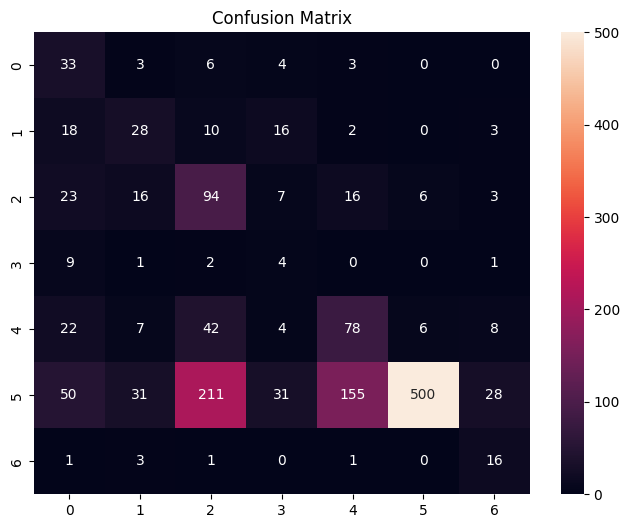

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Analysis


- The diagonal values represent correct predictions. The model performs best on class 5 (500 correct predictions), which is the majority class.
- There is significant confusion between classes, especially where class 5 is misclassified as other classes and vice versa.
- Minority classes (class 3 and class 6) have very few correct predictions, indicating poor performance.
- Many samples from other classes are incorrectly predicted as class 5, showing a bias toward the dominant class.

This confirms that the model is strongly influenced by class imbalance and tends to favor the majority class, leading to poor generalization on minority classes.